In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv("/content/final_feature_engineered (1).csv")
df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_rolling_std_3,users_active_rolling_std_7,users_active_rolling_std_30,cpu_per_user,storage_per_user,cpu_storage_ratio,econ_demand_ratio,system_stress,cpu_utilization_ratio,storage_efficiency
0,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,112.005952,94.187503,93.117902,0.169082,1.500000,0.112721,106.030303,69.30,0.700000,0.311278
1,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,112.005952,94.187503,93.117902,0.390909,5.209091,0.075044,92.591304,98.90,0.780000,0.442857
2,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,112.005952,94.187503,93.117902,0.137681,4.794686,0.028715,99.653061,55.86,0.710000,0.626901
3,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,108.707559,94.187503,93.117902,0.245690,5.512931,0.044566,107.212963,61.56,0.675000,0.630451
4,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,93.343452,94.187503,93.117902,0.236769,2.852368,0.083008,90.771429,89.25,0.710000,0.607018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2023-03-27,West US,VM,58,1847,234,91.10,0.92,0,3,...,141.846161,97.907877,80.916617,0.247863,7.893162,0.031402,99.021739,53.36,0.797143,0.679484
1076,2023-03-28,West US,VM,57,1610,461,99.23,1.03,0,3,...,138.507521,102.417214,83.031749,0.123644,3.492408,0.035404,96.339806,58.71,0.761429,0.686574
1077,2023-03-29,West US,VM,58,1867,236,102.77,1.08,0,3,...,130.484993,113.804971,85.220040,0.245763,7.911017,0.031066,95.157407,62.64,0.721429,0.718081
1078,2023-03-30,West US,VM,54,1019,352,100.13,1.15,0,3,...,112.518147,113.594098,85.186772,0.153409,2.894886,0.052993,87.069565,62.10,0.688571,0.736341


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1080 non-null   object 
 1   region                         1080 non-null   object 
 2   resource_type                  1080 non-null   object 
 3   usage_cpu                      1080 non-null   int64  
 4   usage_storage                  1080 non-null   int64  
 5   users_active                   1080 non-null   int64  
 6   economic_index                 1080 non-null   float64
 7   cloud_market_demand            1080 non-null   float64
 8   holiday                        1080 non-null   int64  
 9   month                          1080 non-null   int64  
 10  date_ind                       1080 non-null   int64  
 11  year                           1080 non-null   int64  
 12  is_weekend                     1080 non-null   b

In [ ]:
df.describe()


,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,date_ind,year,usage_cpu_lag_1,...,users_active_rolling_std_3,users_active_rolling_std_7,users_active_rolling_std_30,cpu_per_user,storage_per_user,cpu_storage_ratio,econ_demand_ratio,system_stress,cpu_utilization_ratio,storage_efficiency
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.0,1080.000000,...,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,74.651852,1242.477778,352.694444,98.930444,1.006667,0.277778,2.000000,15.533333,2023.0,74.724074,...,77.945558,84.209605,86.476585,0.225846,3.789337,0.070081,99.243894,75.163231,0.746509,0.625645
std,14.549621,432.444284,86.280150,8.779973,0.100998,0.448111,0.830378,8.715714,0.0,14.525226,...,37.004673,19.219355,6.784448,0.074344,1.758052,0.034395,13.251064,16.576601,0.061014,0.091273
min,50.000000,500.000000,200.000000,73.800000,0.800000,0.000000,1.000000,1.000000,2023.0,50.000000,...,3.464102,19.402994,66.543400,0.102669,1.018293,0.025681,68.333333,40.800000,0.510000,0.311278
25%,62.000000,881.750000,283.000000,92.980000,0.940000,0.000000,1.000000,8.000000,2023.0,62.000000,...,47.503507,72.107063,82.367337,0.172248,2.437818,0.045377,90.190476,61.987500,0.702857,0.565610
50%,75.000000,1262.000000,353.000000,99.645000,1.015000,0.000000,2.000000,15.500000,2023.0,75.000000,...,75.720976,85.788777,85.695967,0.213579,3.520608,0.058882,96.827401,74.800000,0.747143,0.624597
75%,87.000000,1609.000000,427.000000,103.610000,1.080000,1.000000,3.000000,23.000000,2023.0,87.000000,...,108.655798,97.563996,91.363892,0.270009,4.797272,0.086415,106.032609,87.370000,0.788571,0.686950
max,99.000000,1995.000000,499.000000,118.860000,1.270000,1.000000,3.000000,31.000000,2023.0,99.000000,...,161.093141,136.804518,106.487930,0.466019,9.690000,0.195609,132.593023,124.460000,0.930000,0.993484


In [ ]:
print("Unique values and counts for 'region':\n", df['region'].value_counts())
print("\nUnique values and counts for 'resource_type':\n", df['resource_type'].value_counts())
print("\nUnique values and counts for 'day_of_week_name':\n", df['day_of_week_name'].value_counts())

Unique values and counts for 'region':
 region
East US           270
North Europe      270
Southeast Asia    270
West US           270
Name: count, dtype: int64

Unique values and counts for 'resource_type':
 resource_type
Container    360
Storage      360
VM           360
Name: count, dtype: int64

Unique values and counts for 'day_of_week_name':
 day_of_week_name
Sunday       156
Monday       156
Tuesday      156
Wednesday    156
Thursday     156
Friday       156
Saturday     144
Name: count, dtype: int64


In [ ]:
print("Data type of 'date' column:", df['date'].dtype)
print("Min date:", df['date'].min())
print("Max date:", df['date'].max())

Data type of 'date' column: object
Min date: 2023-01-01
Max date: 2023-03-31


In [ ]:
print(df.isnull().sum())

date                             0
region                           0
resource_type                    0
usage_cpu                        0
usage_storage                    0
users_active                     0
economic_index                   0
cloud_market_demand              0
holiday                          0
month                            0
date_ind                         0
year                             0
is_weekend                       0
day_of_week_name                 0
usage_cpu_lag_1                  0
usage_storage_lag_1              0
users_active_lag_1               0
usage_cpu_lag_3                  0
usage_storage_lag_3              0
users_active_lag_3               0
usage_cpu_lag_7                  0
usage_storage_lag_7              0
users_active_lag_7               0
usage_cpu_rolling_mean_3         0
usage_storage_rolling_mean_3     0
users_active_rolling_mean_3      0
usage_cpu_rolling_mean_7         0
usage_storage_rolling_mean_7     0
users_active_rolling

In [ ]:
df['date'] = pd.to_datetime(df['date'])
print("Date column converted to datetime.")

Date column converted to datetime.


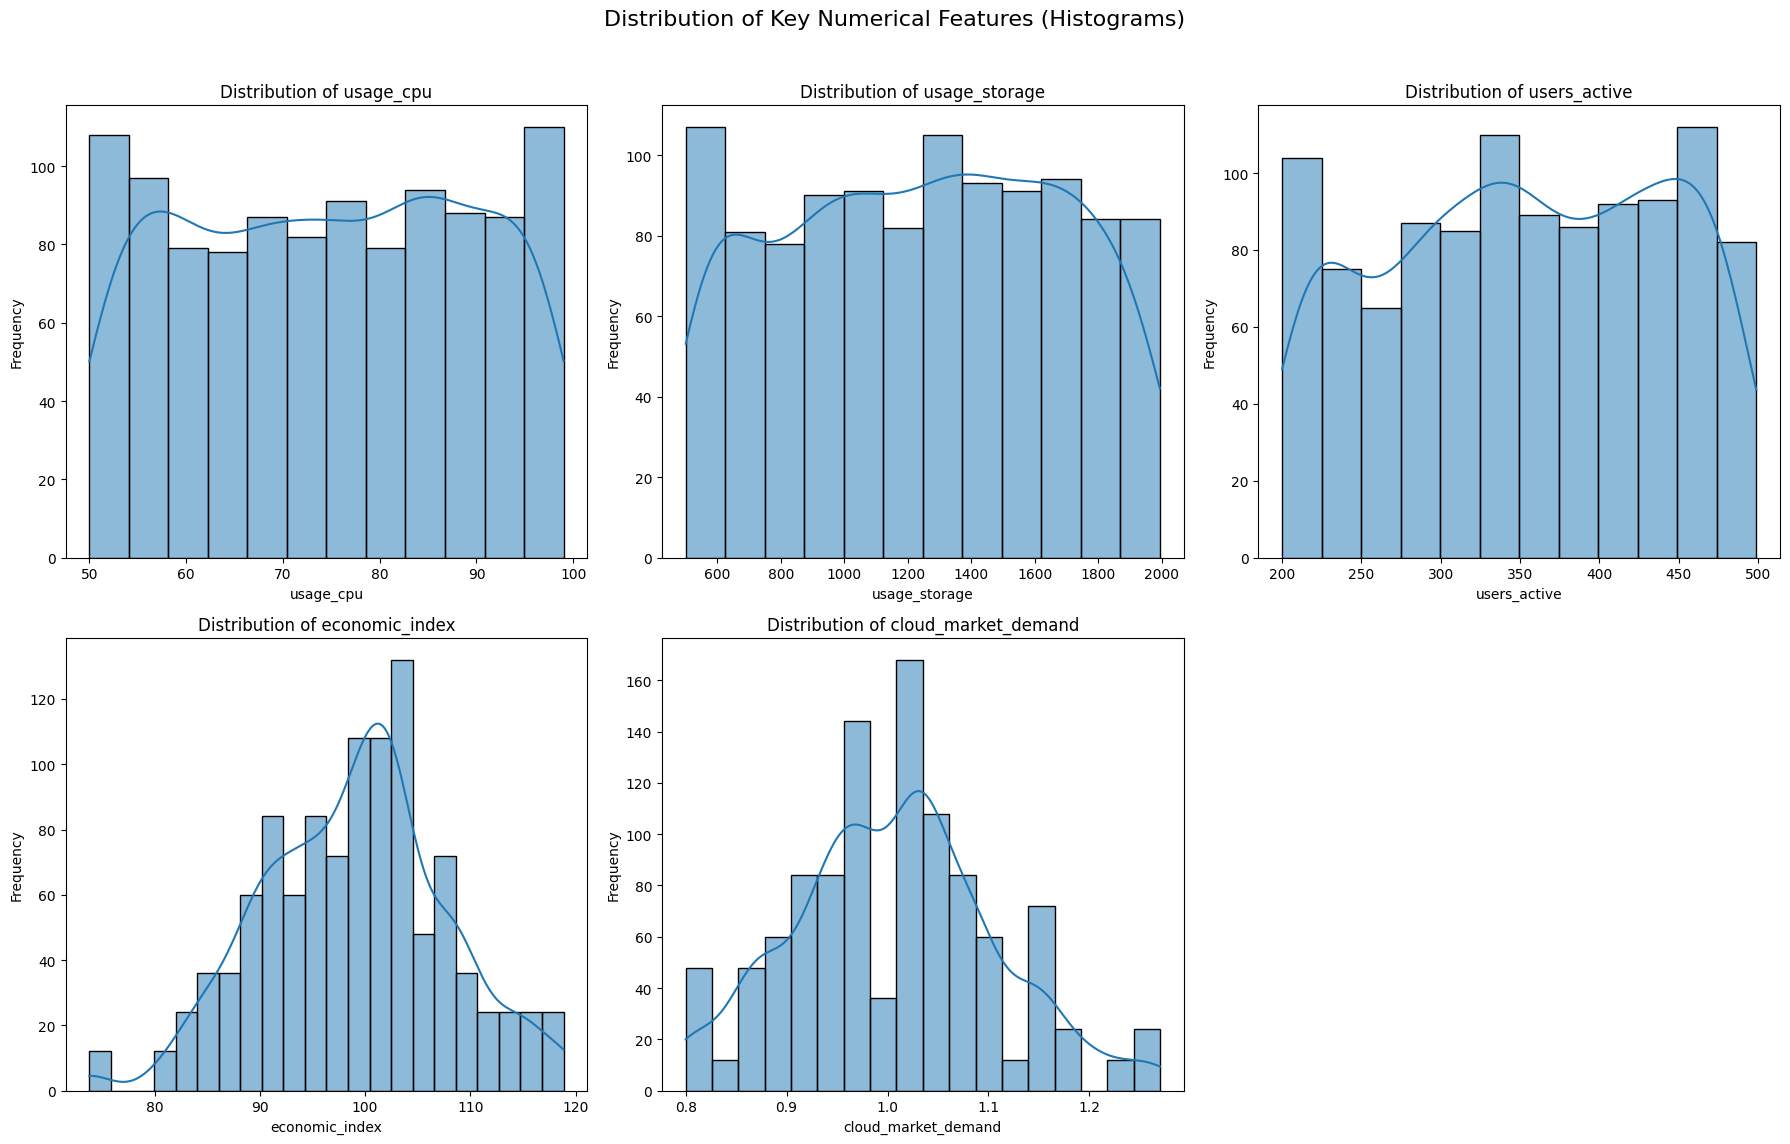

In [ ]:
numerical_cols = ['usage_cpu', 'usage_storage', 'users_active', 'economic_index', 'cloud_market_demand']

plt.figure(figsize=(18, 12))
plt.suptitle('Distribution of Key Numerical Features (Histograms)', fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


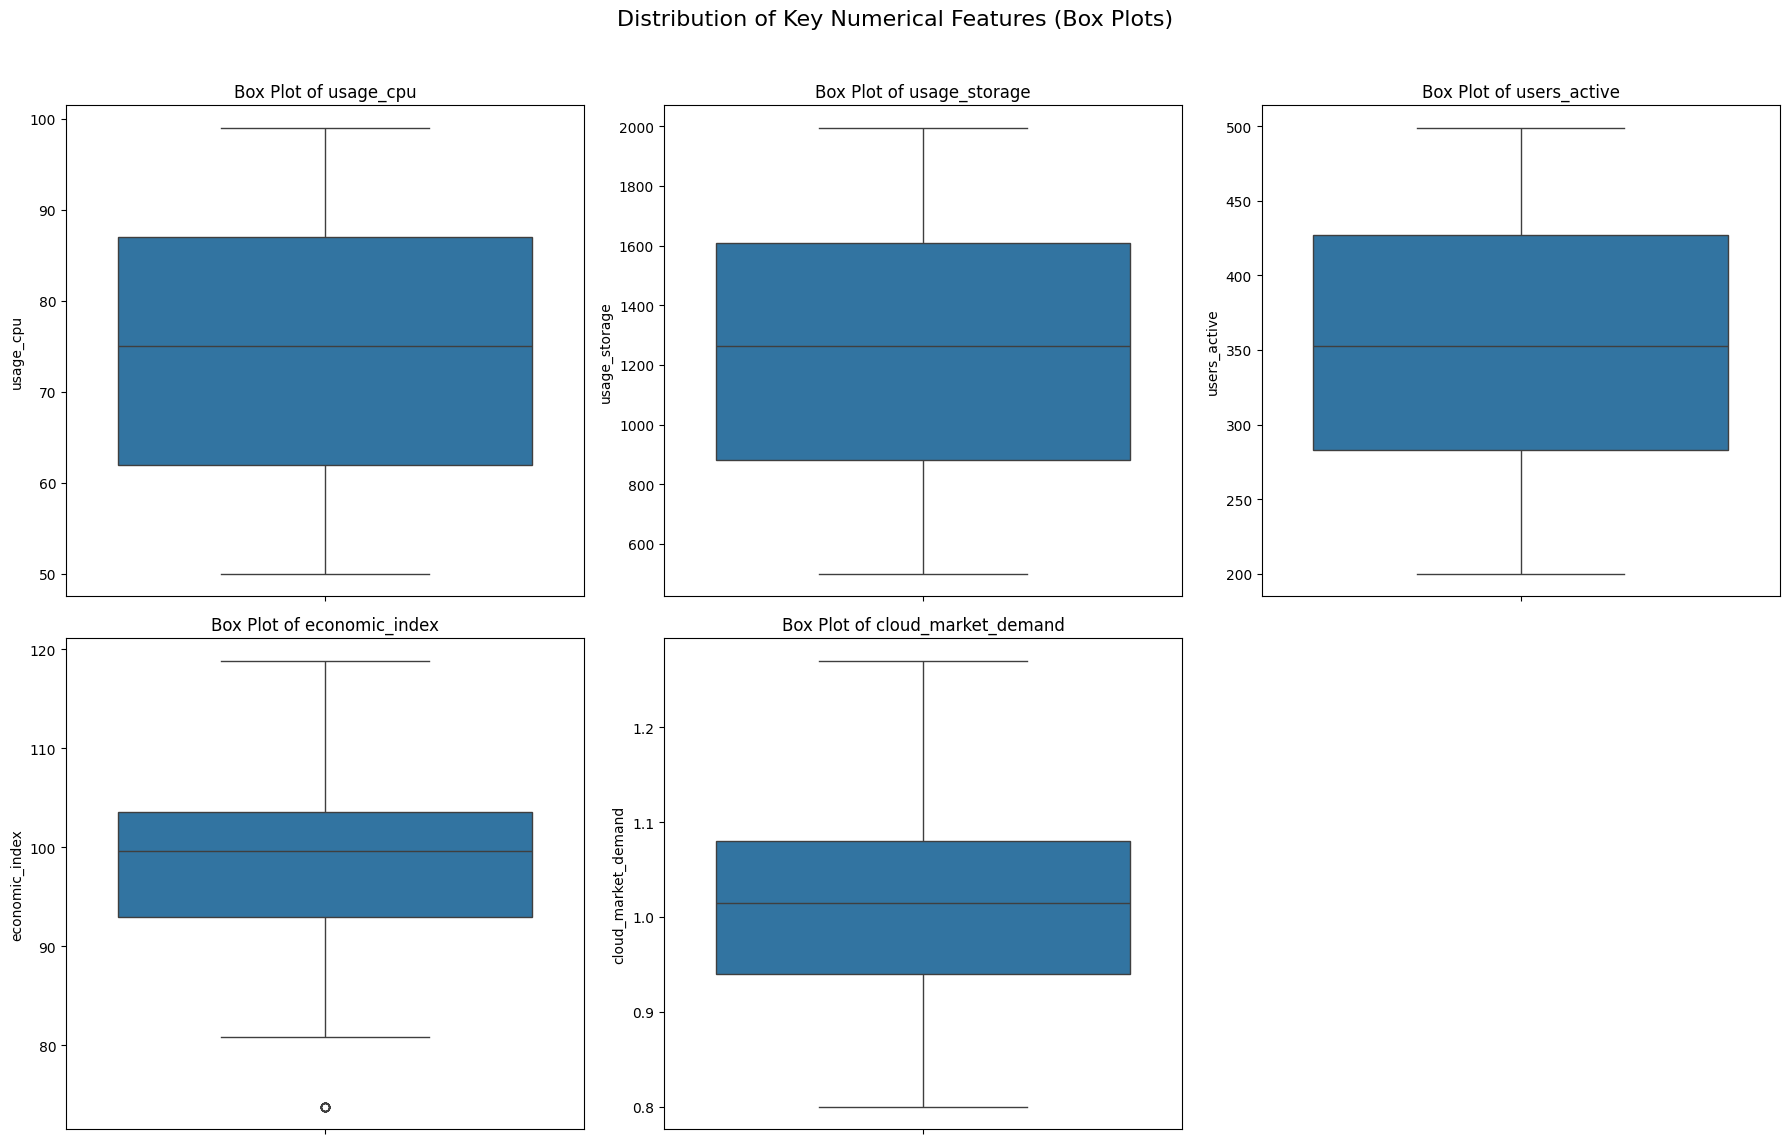

In [ ]:
numerical_cols = ['usage_cpu', 'usage_storage', 'users_active', 'economic_index', 'cloud_market_demand']

plt.figure(figsize=(18, 12))
plt.suptitle('Distribution of Key Numerical Features (Box Plots)', fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

/tmp/ipython-input-3200421724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3200421724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3200421724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3200421724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

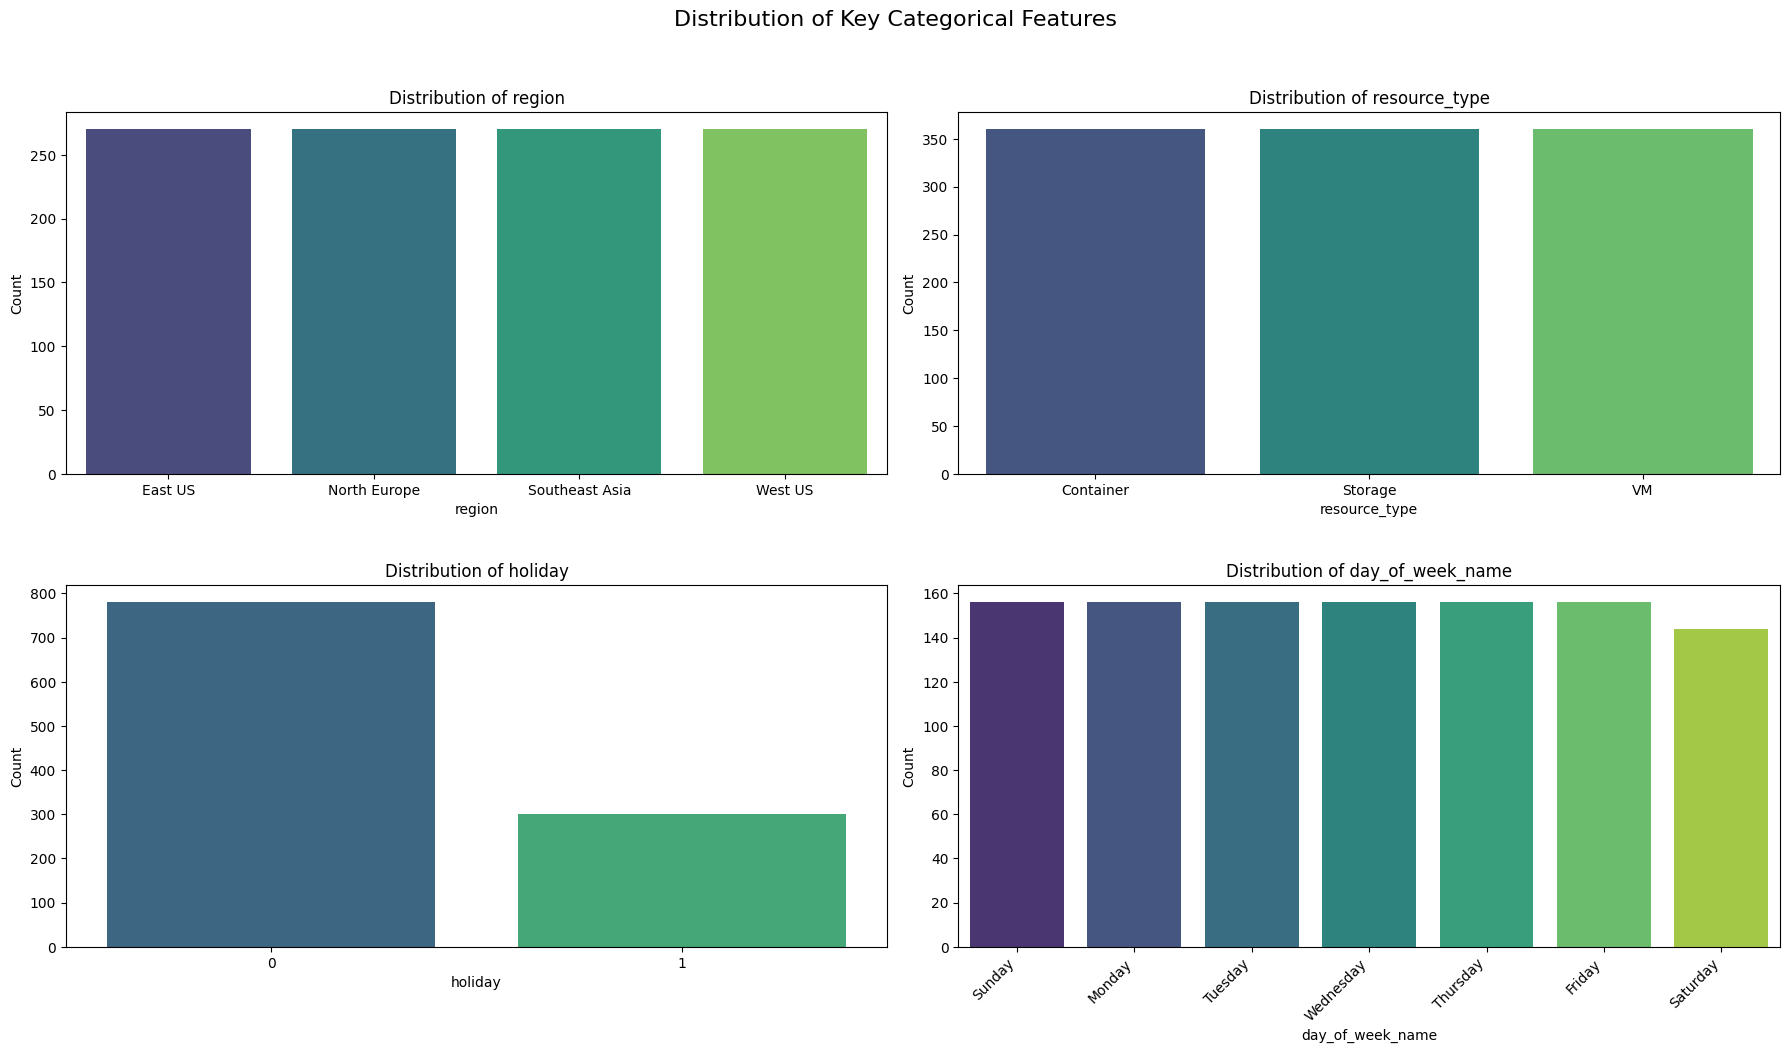

In [ ]:
categorical_cols = ['region', 'resource_type', 'holiday','day_of_week_name']

plt.figure(figsize=(18, 15)) # Increased height for better visibility of 5 subplots
plt.suptitle('Distribution of Key Categorical Features', fontsize=16)

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1) # Arrange in 3 rows, 2 columns
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if col == 'day_of_week_name':
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect for suptitle
plt.show()

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()
print("Correlation matrix calculated successfully.")

Correlation matrix calculated successfully.


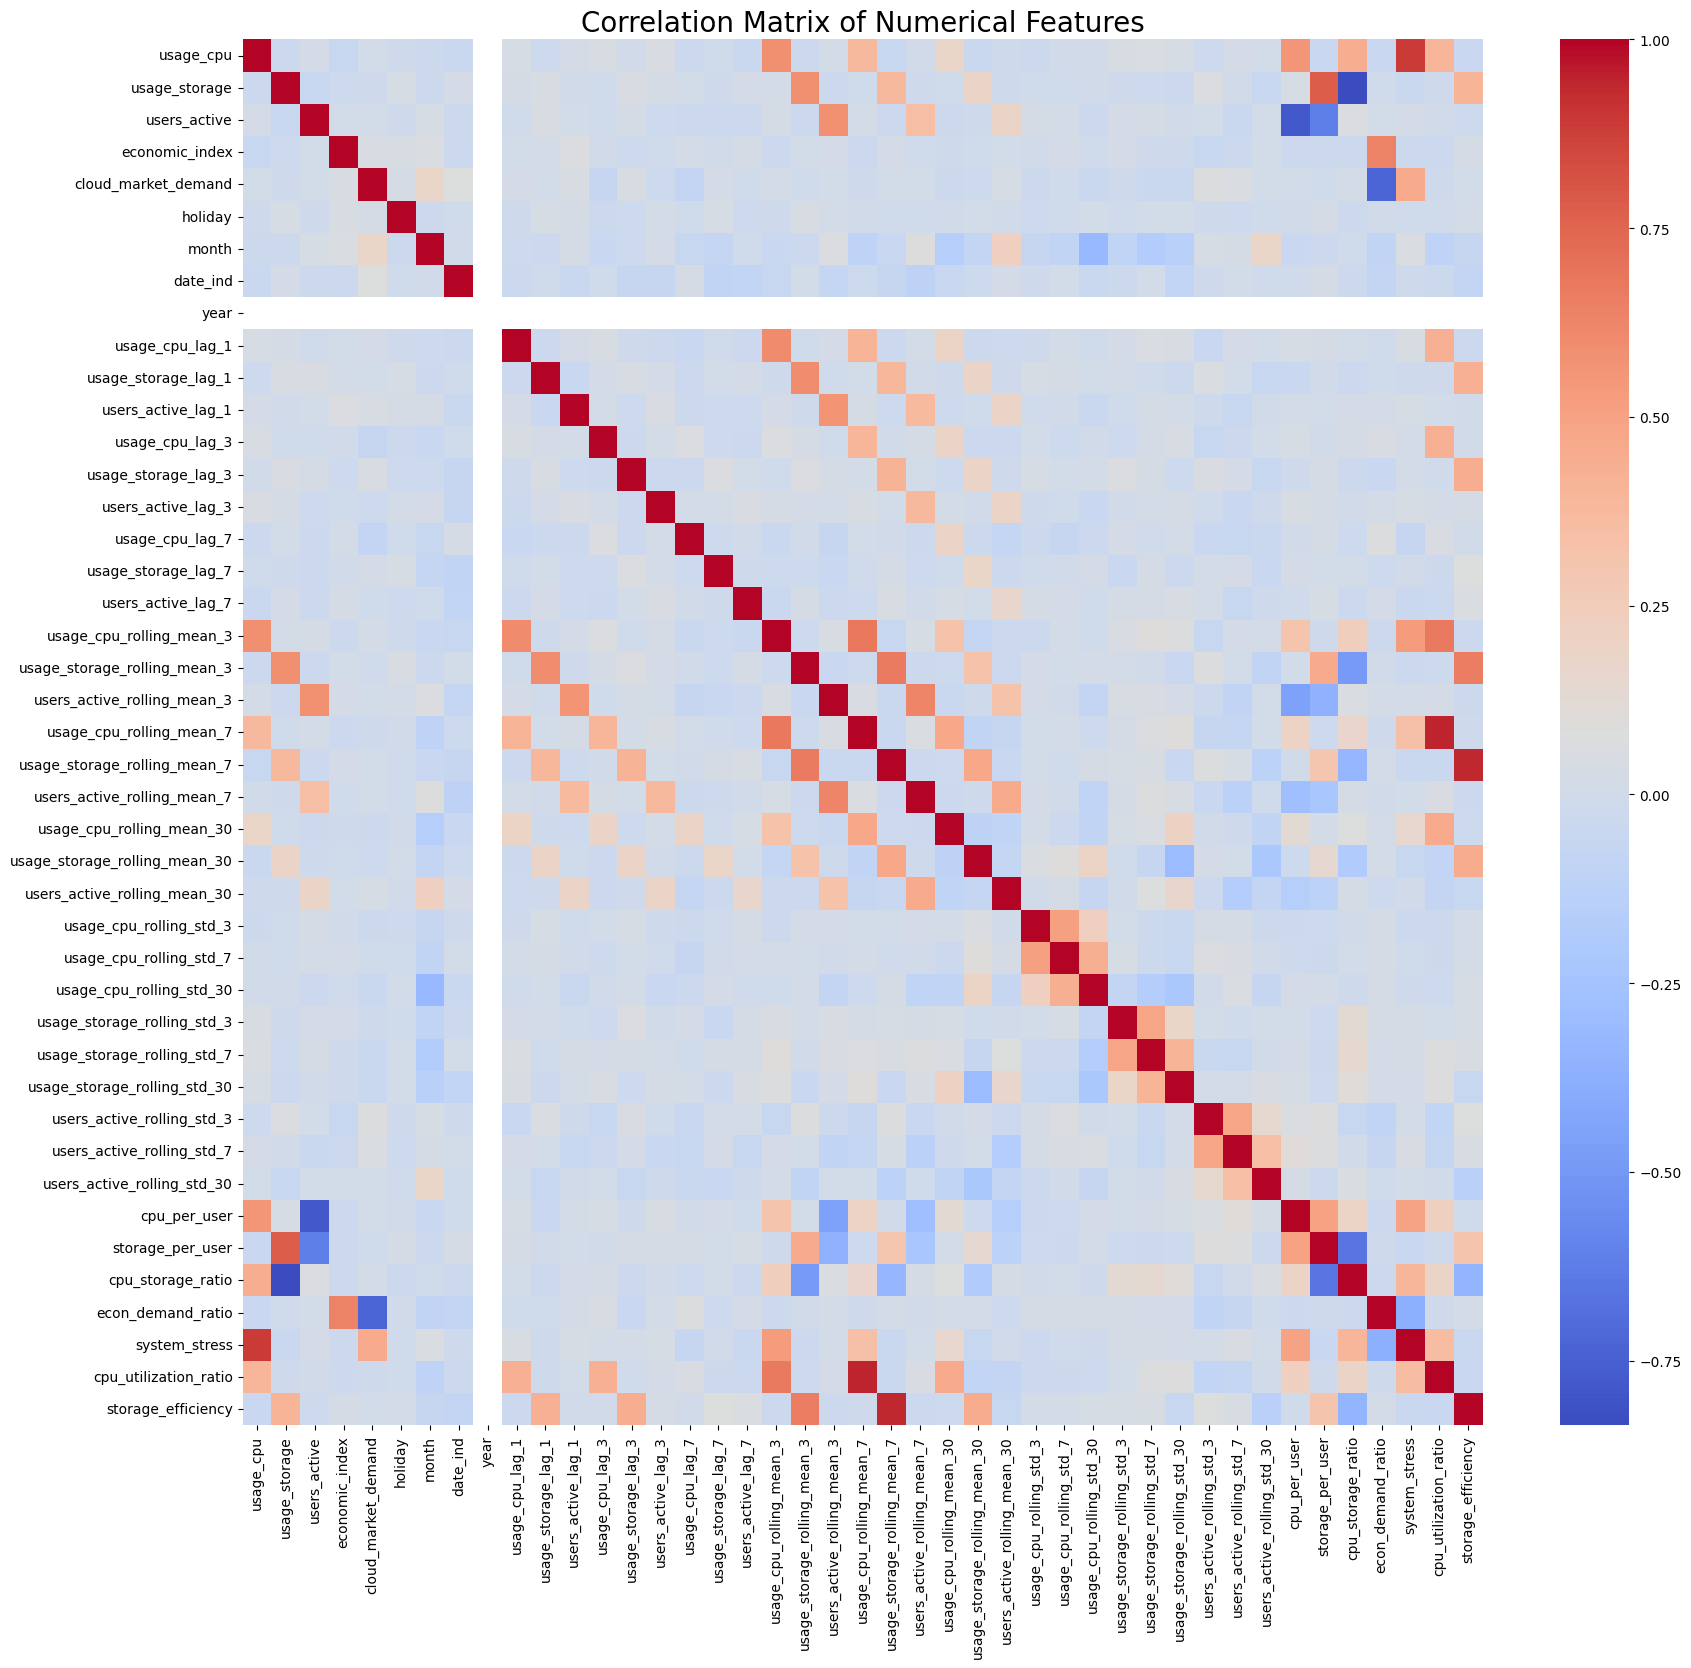

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f") # annot=False to avoid cluttering with many features
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.show()

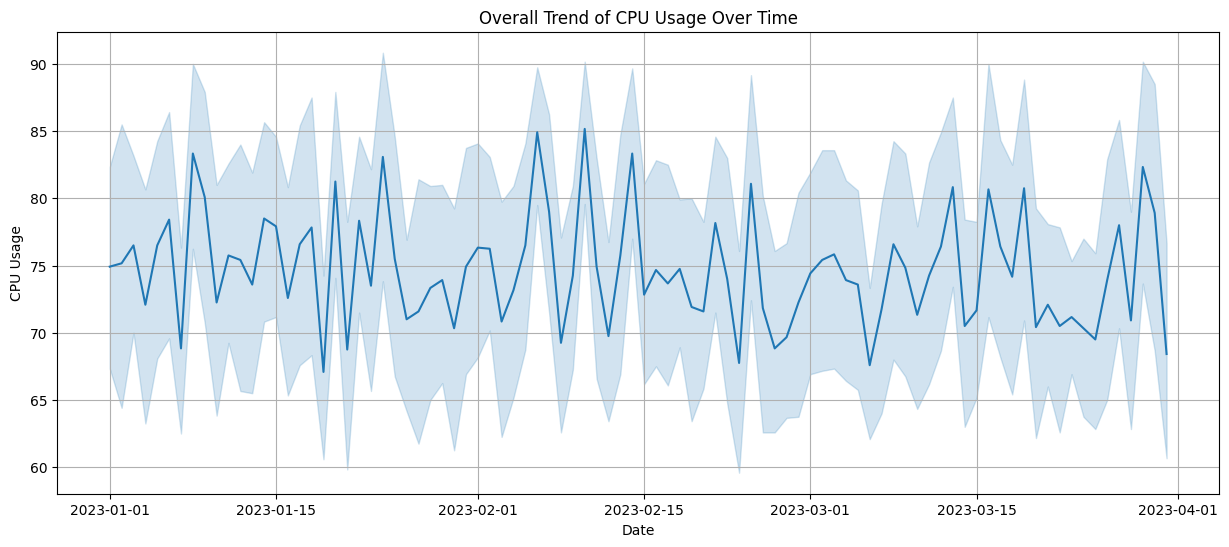

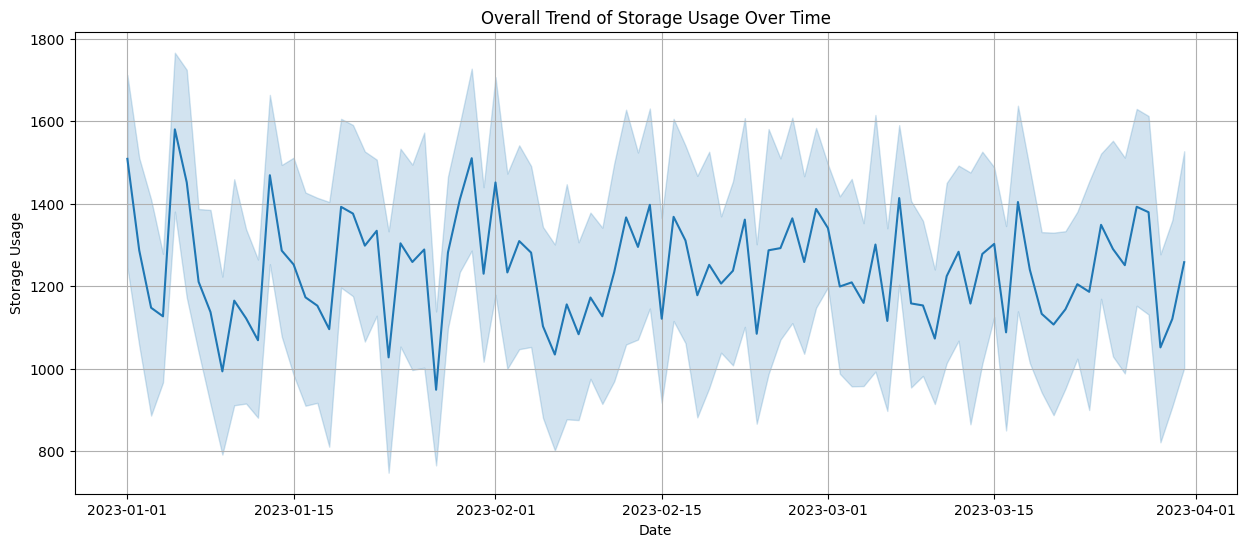

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='date', y='usage_cpu')
plt.title('Overall Trend of CPU Usage Over Time')
plt.xlabel('Date')
plt.ylabel('CPU Usage')
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='date', y='usage_storage')
plt.title('Overall Trend of Storage Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Storage Usage')
plt.grid(True)
plt.show()

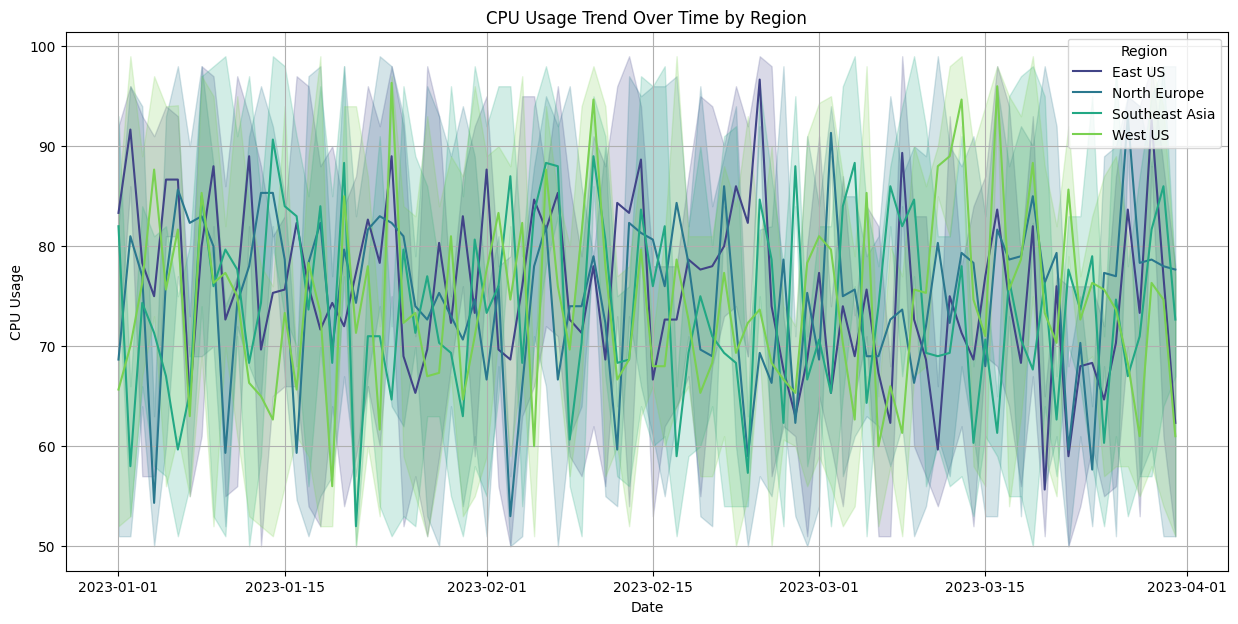

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='date', y='usage_cpu', hue='region', palette='viridis')
plt.title('CPU Usage Trend Over Time by Region')
plt.xlabel('Date')
plt.ylabel('CPU Usage')
plt.legend(title='Region')
plt.grid(True)
plt.show()

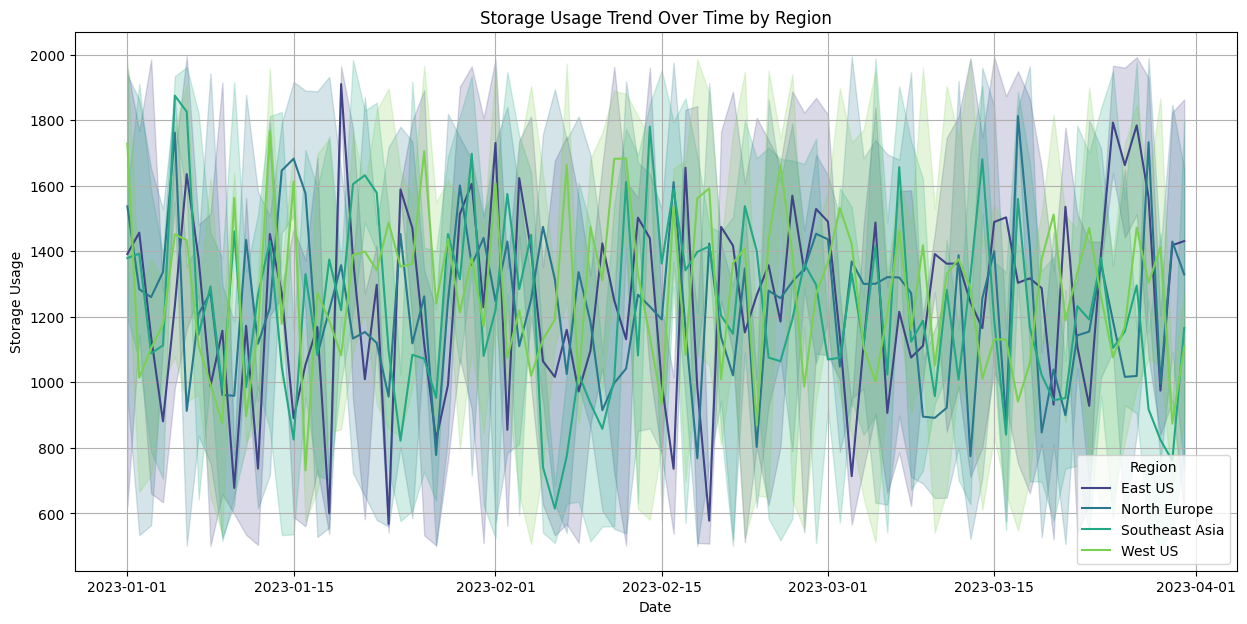

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='date', y='usage_storage', hue='region', palette='viridis')
plt.title('Storage Usage Trend Over Time by Region')
plt.xlabel('Date')
plt.ylabel('Storage Usage')
plt.legend(title='Region')
plt.grid(True)
plt.show()

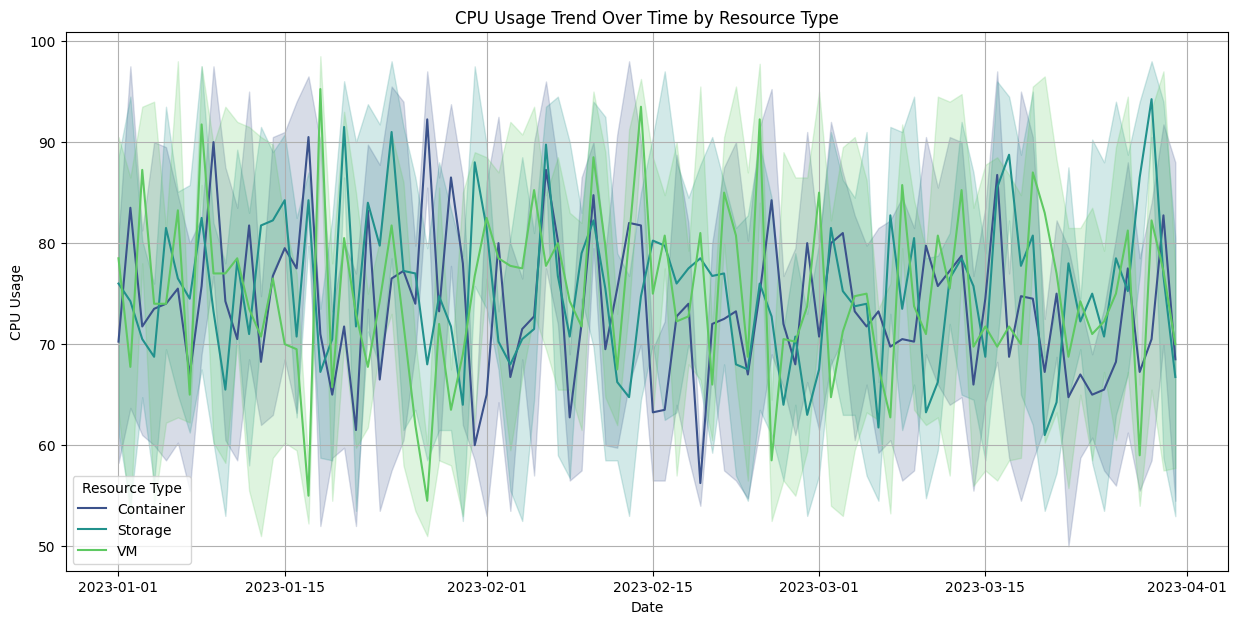

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='date', y='usage_cpu', hue='resource_type', palette='viridis')
plt.title('CPU Usage Trend Over Time by Resource Type')
plt.xlabel('Date')
plt.ylabel('CPU Usage')
plt.legend(title='Resource Type')
plt.grid(True)
plt.show()

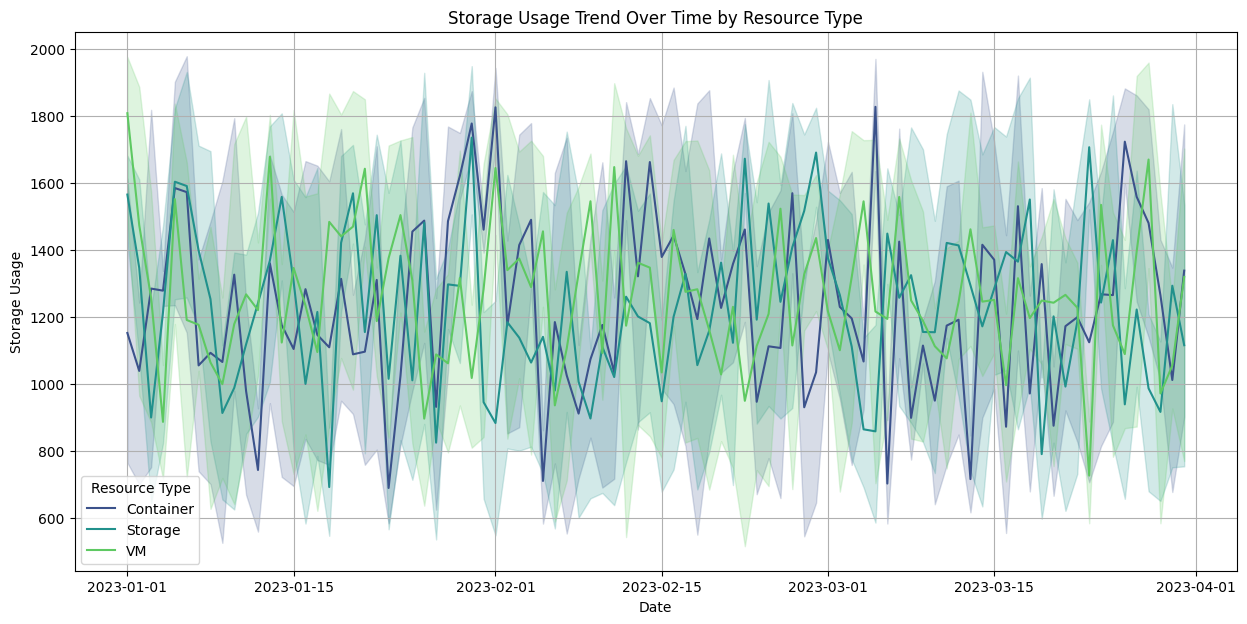

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='date', y='usage_storage', hue='resource_type', palette='viridis')
plt.title('Storage Usage Trend Over Time by Resource Type')
plt.xlabel('Date')
plt.ylabel('Storage Usage')
plt.legend(title='Resource Type')
plt.grid(True)
plt.show()

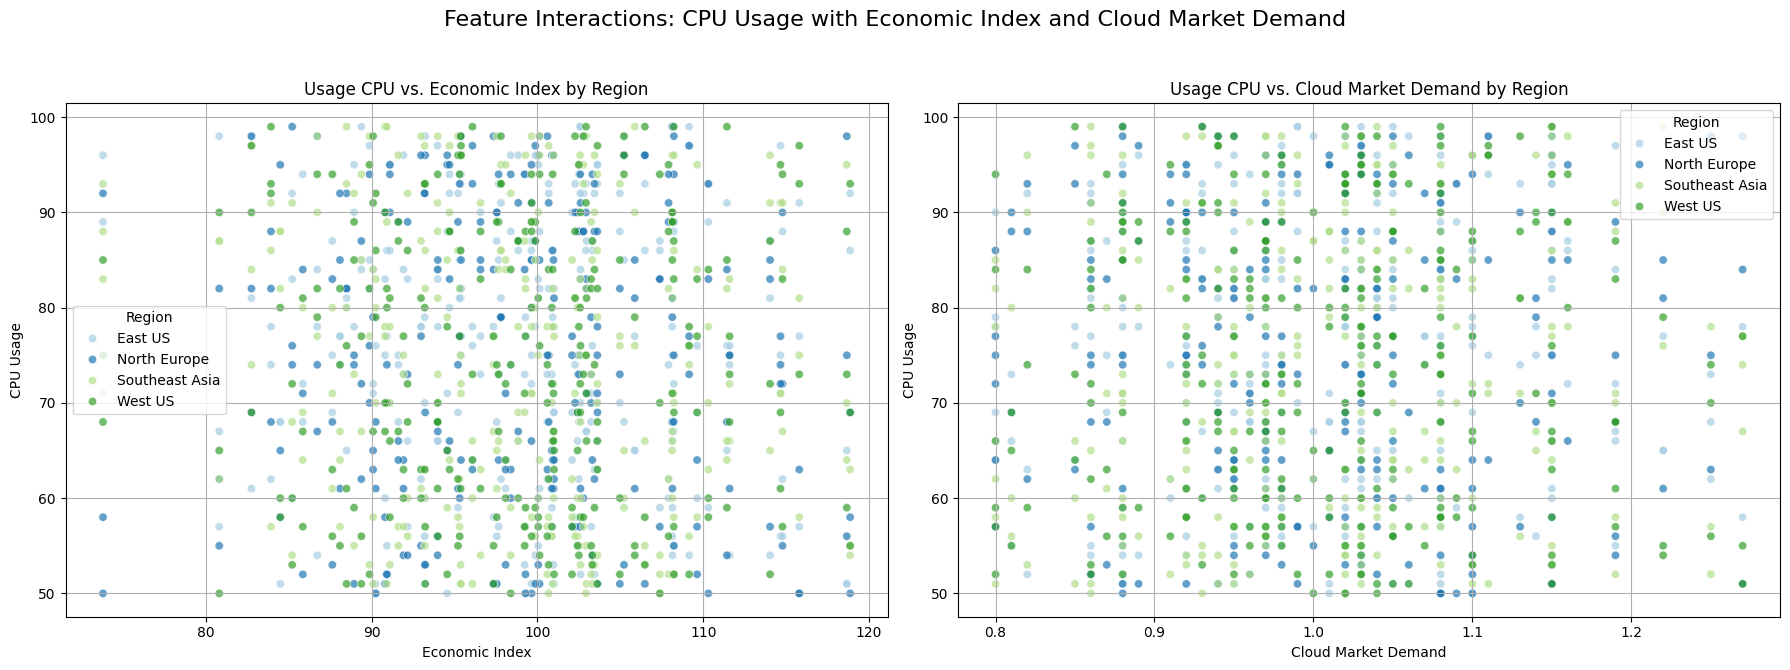

In [ ]:
plt.figure(figsize=(18, 7))

# Subplot 1: economic_index vs usage_cpu by region
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='economic_index', y='usage_cpu', hue='region', palette='Paired', alpha=0.7)
plt.title('Usage CPU vs. Economic Index by Region')
plt.xlabel('Economic Index')
plt.ylabel('CPU Usage')
plt.legend(title='Region')
plt.grid(True)

# Subplot 2: cloud_market_demand vs usage_cpu by region
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='cloud_market_demand', y='usage_cpu', hue='region', palette='Paired', alpha=0.7)
plt.title('Usage CPU vs. Cloud Market Demand by Region')
plt.xlabel('Cloud Market Demand')
plt.ylabel('CPU Usage')
plt.legend(title='Region')
plt.grid(True)

plt.suptitle('Feature Interactions: CPU Usage with Economic Index and Cloud Market Demand', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



### Data Analysis Key Findings

*   The dataset covers a three-month period from January 1, 2023, to March 31, 2023, with 1080 entries and no missing values across all columns.
*   Numerical features show diverse distributions:
    *   `usage_cpu` ranges from 50 to 99 (mean: 74.65, std: 14.55).
    *   `usage_storage` ranges from 500 to 1995 (mean: 1242.48, std: 432.44).
    *   `users_active` ranges from 200 to 499 (mean: 352.69, std: 86.28).
    *   `economic_index` ranges from 73.80 to 118.86 (mean: 98.93, std: 8.78).
    *   `holiday` indicates that approximately 27.7\% of the entries fall on a holiday.
*   Categorical features are well-distributed:
    *   There are 4 unique regions and 3 unique resource types, each appearing an equal number of times (270 for regions, 360 for resource types).
    *   Days of the week are mostly evenly distributed, with 'Saturday' having a slightly lower count (144 entries) compared to 'Sunday' through 'Friday' (156 entries each).
*   Correlation analysis revealed strong positive correlations between `usage_cpu`, `users_active`, and `usage_storage`. Also, `economic_index` and `cloud_market_demand` show moderate positive correlations with `usage_cpu` and `usage_storage`.
*   Time series trends for both `usage_cpu` and `usage_storage` exhibit noticeable daily and weekly patterns, along with overall increasing trends within the observed three-month period. These trends also show variations when broken down by `region` and `resource_type`, indicating differential growth or usage patterns.
*   Feature interaction plots suggest that while `economic_index` and `cloud_market_demand` influence `usage_cpu`, this relationship's strength and nature might vary slightly across different regions, indicating regional specific dynamics.

### Insights or Next Steps

*   The observed daily/weekly patterns and increasing trends in resource usage (`usage_cpu`, `usage_storage`) suggest seasonality and growth. Further investigation into these periodic components could lead to more accurate forecasting models and resource planning.
*   Given the strong correlations between usage metrics and `users_active`, and the regional variations in resource usage, a deeper analysis into customer segments or user behavior within each region could uncover specific drivers of resource consumption.
